## Общая информация

**Срок сдачи:** 5 апреля 2022, 08:30 

**Штраф за опоздание:** по 1 баллу за 24 часа задержки. Через 5 дней домашнее задание сгорает.

При отправлении ДЗ указывайте фамилию в названии файла
Присылать ДЗ необходимо в виде ссылки на свой github репозиторий на почту ml1.sphere@mail.ru с указанием темы в следующем формате:

[ML0220, Задание 1] Фамилия Имя.

Используйте данный Ipython Notebook при оформлении домашнего задания.


**Штрафные баллы:**

1. Отсутствие фамилии в имени скрипта (скрипт должен называться по аналогии со stroykova_hw1.ipynb) -0.5 баллов
2. Все строчки должны быть выполнены. Нужно, чтобы output команды можно было увидеть уже в git'е. В противном случае -0.5 баллов


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn import datasets
from sklearn.base import BaseEstimator
from sklearn.datasets import fetch_openml, fetch_20newsgroups

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, pairwise_distances
from sklearn.neighbors import KDTree

from sklearn.feature_extraction.text import CountVectorizer

### Задание 1 (1 балл)
Реализовать KNN в классе MyKNeighborsClassifier (обязательное условие: точность не ниже sklearn реализации)
Разберитесь самостоятельно, какая мера расстояния используется в KNeighborsClassifier дефолтно и реализуйте свой алгоритм именно с этой мерой. 
Для подсчета расстояний можно использовать функции [отсюда](https://docs.scipy.org/doc/scipy/reference/spatial.distance.html)

In [2]:
class MyKNeighborsClassifier(BaseEstimator):
    
    def __init__(self, n_neighbors, algorithm='brute', metric='minkowski'):
        self.n_neighbors = n_neighbors
        self.algorithm = algorithm
        self.metric = metric
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        
    def kd_tree_predict(self, X):
        y_test = np.zeros(X.shape[0], dtype=int)
        ind_of_label = KDTree(self.X_train, metric=self.metric).query(X, self.n_neighbors, return_distance=False)
        for i in range(X.shape[0]):
            y_test[i] = np.argmax(np.bincount(self.y_train[ind_of_label[i]]))
        return y_test
    
    def brute_predict(self, X):
        y_test = np.zeros(X.shape[0], dtype=int)
        ind_of_label = np.argpartition(pairwise_distances(X, self.X_train, metric=self.metric), self.n_neighbors - 1, axis=1)[:, :self.n_neighbors]
        for i in range(X.shape[0]):
            y_test[i] = np.argmax(np.bincount(self.y_train[ind_of_label[i]]))
        return y_test
    
    def predict(self, X):
        if self.algorithm == 'kd_tree':
            return self.kd_tree_predict(X)
        else:
            return self.brute_predict(X)

**IRIS**

В библиотеке scikit-learn есть несколько датасетов из коробки. Один из них [Ирисы Фишера](https://ru.wikipedia.org/wiki/%D0%98%D1%80%D0%B8%D1%81%D1%8B_%D0%A4%D0%B8%D1%88%D0%B5%D1%80%D0%B0)

In [3]:
iris = datasets.load_iris()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.1, stratify=iris.target)

In [5]:
clf = KNeighborsClassifier(n_neighbors=2, algorithm='brute')
my_clf = MyKNeighborsClassifier(n_neighbors=2, algorithm='brute')

In [6]:
clf.fit(X_train, y_train)
my_clf.fit(X_train, y_train)

In [7]:
sklearn_pred = clf.predict(X_test)
my_clf_pred = my_clf.predict(X_test)
print(accuracy_score(y_test, my_clf_pred))
print(accuracy_score(y_test, sklearn_pred))
assert abs( accuracy_score(y_test, my_clf_pred) -  accuracy_score(y_test, sklearn_pred ) )<0.005, "Score must be simillar"

0.8
0.8


### Задание 2 (0.5 балла)

Давайте попробуем добиться скорости работы на fit, predict сравнимой со sklearn для iris. Допускается замедление не более чем в 2 раза. 
Для этого используем numpy. 

In [8]:
%time clf.fit(X_train, y_train)

CPU times: user 0 ns, sys: 0 ns, total: 0 ns
Wall time: 788 µs


KNeighborsClassifier(algorithm='brute', n_neighbors=2)

In [9]:
%time my_clf.fit(X_train, y_train)

CPU times: user 0 ns, sys: 0 ns, total: 0 ns
Wall time: 10.3 µs


In [10]:
%time clf.predict(X_test)

CPU times: user 0 ns, sys: 0 ns, total: 0 ns
Wall time: 3.22 ms


array([2, 1, 0, 0, 0, 0, 0, 1, 1, 2, 1, 2, 2, 1, 1])

In [11]:
%time my_clf.predict(X_test)

CPU times: user 0 ns, sys: 0 ns, total: 0 ns
Wall time: 1.93 ms


array([2, 1, 0, 0, 0, 0, 0, 1, 1, 2, 1, 2, 2, 1, 1])

### Задание 3 (1 балл)
Добавьте algorithm='kd_tree' в реализацию KNN (использовать KDTree из sklearn.neighbors). Необходимо добиться скорости работы на fit,  predict сравнимой со sklearn для iris. Допускается замедление не более чем в 2 раза. 
Для этого используем numpy. Точность не должна уступать значению KNN из sklearn. 

In [12]:
clf = KNeighborsClassifier(n_neighbors=2, algorithm='kd_tree')
my_clf = MyKNeighborsClassifier(n_neighbors=2, algorithm='kd_tree')

In [13]:
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.1, stratify=iris.target)

In [14]:
%time clf.fit(X_train, y_train)

CPU times: user 0 ns, sys: 0 ns, total: 0 ns
Wall time: 1.3 ms


KNeighborsClassifier(algorithm='kd_tree', n_neighbors=2)

In [15]:
%time my_clf.fit(X_train, y_train)

CPU times: user 0 ns, sys: 0 ns, total: 0 ns
Wall time: 12.4 µs


In [16]:
%time clf.predict(X_test)

CPU times: user 0 ns, sys: 0 ns, total: 0 ns
Wall time: 2.24 ms


array([2, 0, 2, 0, 2, 1, 2, 1, 0, 2, 0, 0, 2, 1, 1])

In [17]:
%time my_clf.predict(X_test)

CPU times: user 0 ns, sys: 0 ns, total: 0 ns
Wall time: 1.23 ms


array([2, 0, 2, 0, 2, 1, 2, 1, 0, 2, 0, 0, 2, 1, 1])

In [18]:
sklearn_pred = clf.predict(X_test)
my_clf_pred = my_clf.predict(X_test)
assert abs( accuracy_score(y_test, my_clf_pred) -  accuracy_score(y_test, sklearn_pred ) )<0.005, "Score must be simillar"

### Задание 4 (2.5 балла)

Рассмотрим новый датасет 20 newsgroups

In [19]:
newsgroups = fetch_20newsgroups(subset='train',remove=['headers','footers', 'quotes'])

In [20]:
data = newsgroups['data']
target = newsgroups['target']

Преобразуйте текстовые данные из data с помощью [CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html). Словарь можно ограничить по частотности.

In [21]:
vectorizer = CountVectorizer(max_df=0.1)
vec_data = vectorizer.fit_transform(data)

*Так мы получили векторное представление наших текстов. Значит можно приступать к задаче обучения модели*

Реализуйте разбиение выборки для кросс-валидации на 3 фолдах. Разрешено использовать sklearn.cross_validation

In [22]:
from sklearn.model_selection import KFold, cross_val_score

In [23]:
kfold = KFold(n_splits=3, shuffle=True)
for train_index, test_index in kfold.split(vec_data):
    print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = vec_data[train_index], vec_data[test_index]
    y_train, y_test = vec_data[train_index], vec_data[test_index]

TRAIN: [    1     4     5 ... 11311 11312 11313] TEST: [    0     2     3 ... 11303 11305 11307]
TRAIN: [    0     2     3 ... 11310 11311 11313] TEST: [    1     4     5 ... 11301 11306 11312]
TRAIN: [    0     1     2 ... 11306 11307 11312] TEST: [    8    11    13 ... 11310 11311 11313]


Напишите метод, позволяющий найти оптимальное количество ближайших соседей(дающее максимальную точность в среднем на валидации на 3 фолдах).
Постройте график зависимости средней точности от количества соседей. Можно рассмотреть число соседей от 1 до 10.

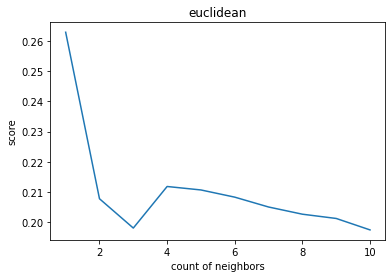

In [33]:
scores = []
for i in range(1, 11):
    my_clf = MyKNeighborsClassifier(n_neighbors=i, algorithm='brute', metric='euclidean')
    scores.append(cross_val_score(my_clf, vec_data, target, cv=3, scoring='accuracy').mean())
    
plt.plot(range(1, 11), scores)
plt.xlabel('count of neighbors')
plt.ylabel('score')
plt.title('euclidean')
plt.show()

Как изменится качество на валидации, если:

1. Используется косинусная метрика вместо евклидовой.
2. К текстам применяется TfIdf векторизацию( sklearn.feature_extraction.text.TfidfVectorizer)

Сравните модели, выберите лучшую.

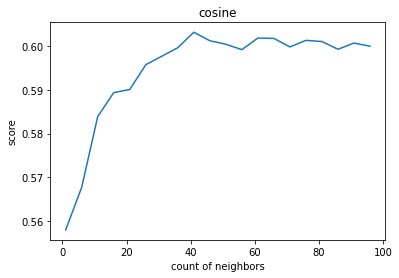

In [25]:
scores = []
for i in range(1, 100, 5):
    my_clf = MyKNeighborsClassifier(n_neighbors=i, algorithm='brute', metric='cosine')
    scores.append(cross_val_score(my_clf, vec_data, target, cv=3, scoring='accuracy').mean())
plt.plot(range(1, 100, 5), scores)
plt.xlabel('count of neighbors')
plt.ylabel('score')
plt.title('cosine')
plt.show()

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_df=0.1)
Tfid_data = vectorizer.fit_transform(data)

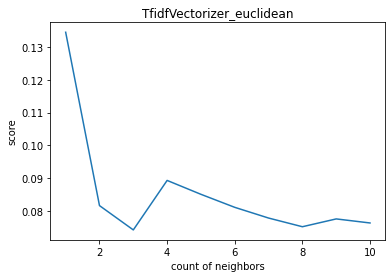

In [27]:
scores = []
for i in range(1, 11):
    my_clf = MyKNeighborsClassifier(n_neighbors=i, algorithm='brute', metric='euclidean')
    scores.append(cross_val_score(my_clf, Tfid_data, target, cv=3, scoring='accuracy').mean())
    
plt.plot(range(1, 11), scores)
plt.xlabel('count of neighbors')
plt.ylabel('score')
plt.title('TfidfVectorizer_euclidean')
plt.show()

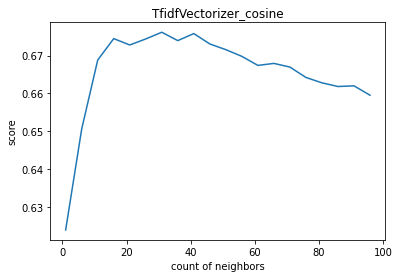

max score and count of neighbors:  (0.6761538002948776, 31)


In [28]:
scores = []
for i in range(1, 100, 5):
    my_clf = MyKNeighborsClassifier(n_neighbors=i, algorithm='brute', metric='cosine')
    scores.append((cross_val_score(my_clf, Tfid_data, target, cv=3, scoring='accuracy').mean(), i))
    
plt.plot(range(1, 100, 5), [x[0] for x in scores])
plt.xlabel('count of neighbors')
plt.ylabel('score')
plt.title('TfidfVectorizer_cosine')
plt.show()

print("max score and count of neighbors: ", sorted(scores)[-1])

Загрузим  теперь test  часть нашей выборки и преобразуем её аналогично с train частью. Не забудьте, что наборы слов в train и test части могут отличаться.

In [29]:
newsgroups = fetch_20newsgroups(subset='test',remove=['headers','footers', 'quotes'])

Оценим точность вашей лучшей модели на test части датасета. Отличается ли оно от кросс-валидации? Попробуйте сделать выводы, почему отличается качество.

In [32]:
test_data = newsgroups['data']
test_target = newsgroups['target']
X_test = vectorizer.fit(data).transform(test_data)
my_clf = MyKNeighborsClassifier(n_neighbors=31, algorithm='brute', metric='cosine')
my_clf.fit(Tfid_data, target)
print(accuracy_score(test_target, my_clf.predict(X_test)))

0.6336962294211365


Результат стал хуже, поскольку отличаются наборы слов на трейне и на тесте.